### 라이브러리 설치 및 Import

In [82]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 시각화

In [83]:
df = pd.read_csv('../../Data/merged_df.csv')

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

### 전체(핵심 지표 소개)

#### 총 오퍼 퍼널 분석

In [85]:
# 총 발송 수
cnt_received = df['customer_id'][df['event']=='received'].count()
print("총 발송 수:")
print(cnt_received)

총 발송 수:
76277


In [86]:
# 총 열람 수
cnt_viewed = df['customer_id'][df['event']=='viewed'].count()
print("총 열람 수:")
print(cnt_viewed)

총 열람 수:
57725


In [87]:
# 총 완료 수
cnt_completed = df['customer_id'][df['event']=='completed'].count()
print("총 완료 수:")
print(cnt_completed)

총 완료 수:
33182


In [88]:
# 발송 → 열람 전환율
ratio_received_viewed = cnt_viewed / cnt_received * 100
print("발송 → 열람 전환율:")
print(f'{ratio_received_viewed:.2f}%')

발송 → 열람 전환율:
75.68%


In [89]:
# 열람 → 완료 전환율
ratio_viewed_completed = cnt_completed / cnt_viewed * 100
print("열람 → 완료 전환율:")
print(f'{ratio_viewed_completed:.2f}%')

열람 → 완료 전환율:
57.48%


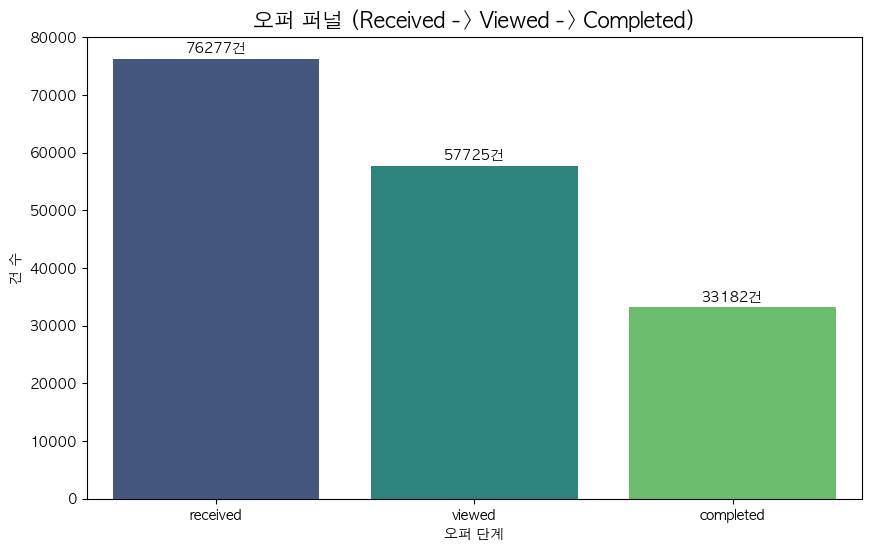

In [90]:
offer_events = ['received', 'viewed', 'completed']
funnel_df = df[df['event'].isin(offer_events)]

overall_funnel = funnel_df['event'].value_counts().reindex(offer_events)

# 시각화 1: 전체 퍼널 현황
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=overall_funnel.index, y=overall_funnel.values, palette='viridis')

plt.title('오퍼 퍼널 (Received -> Viewed -> Completed)', fontsize=15)
plt.ylabel('건 수')
plt.xlabel('오퍼 단계')

# 막대 위에 값 표시
for i, v in enumerate(overall_funnel):
    ax.text(i, v + 1000, f"{v:.0f}건", ha='center')

plt.show()

#### 전체 매출 관련

In [91]:
# 총 매출
total_revenue = df['amount'].sum()
print("총 매출:")
print(f'${total_revenue:,.0f}')

총 매출:
$1,775,452


In [92]:
# 총 거래 건수
total_cnt = df['amount'].count()
print("총 거래 건수:")
print(f'{total_cnt:,}')

총 거래 건수:
138,953


In [93]:
df['amount'].describe()

count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

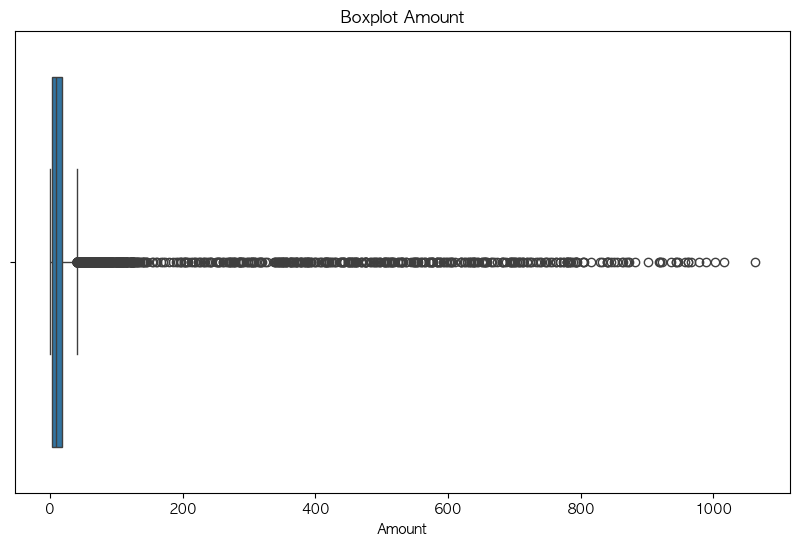

In [94]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['amount'].dropna())
plt.title('Boxplot Amount')
plt.xlabel('Amount')
plt.show()

#### 객단가

In [95]:
# 객단가(AOV - Average order value, 거래별 객단가) = 총 매출 / 총 거래 건수
aov = total_revenue / total_cnt
print("객단가(AOV):")
print(f'${aov:,.2f}')

객단가(AOV):
$12.78


In [96]:
# 총 고객별 객단가(ARPU - Average Revenue Per User) = 총 매출 / 총 고객 수
total_cnt_customer = df['customer_id'].count()

arpu = total_revenue / total_cnt_customer
print("객단가(ARPU):")
print(f'${arpu:,.2f}')

객단가(ARPU):
$5.80


In [97]:
# 고객별 객단가 = 고객별 총 매출 / 고객별 거래 수
transactions = df[df['event'] == 'transaction'] 

customer_stats = transactions.groupby('person')['amount'].agg(['sum', 'count', 'mean']).reset_index() 

print(customer_stats.head())

                             person     sum  count       mean
0  0009655768c64bdeb2e877511632db8f  127.60      8  15.950000
1  00116118485d4dfda04fdbaba9a87b5c    4.09      3   1.363333
2  0011e0d4e6b944f998e987f904e8c1e5   79.46      5  15.892000
3  0020c2b971eb4e9188eac86d93036a77  196.86      8  24.607500
4  0020ccbbb6d84e358d3414a3ff76cffd  154.05     12  12.837500


#### 채널별 offer 고객 수(중복 O): 1개 offer에 제공되는 채널이 여러 개이므로

In [98]:
# 채널별 고객 수
cnt_web_customer = df['customer_id'][df['web']==1].count()
cnt_email_customer = df['customer_id'][df['email']==1].count()
cnt_mobile_customer = df['customer_id'][df['mobile']==1].count()
cnt_social_customer = df['customer_id'][df['social']==1].count()

print("채널별 고객 수:")
print(f'web: {cnt_web_customer:,}명')
print(f'email: {cnt_email_customer:,}명')
print(f'mobile: {cnt_mobile_customer:,}명')
print(f'social: {cnt_social_customer:,}명')

채널별 고객 수:
web: 134,870명
email: 167,184명
mobile: 153,513명
social: 109,887명


> 발송이 되어야만 열람/완료가 진행되는 구조라면,  
> 발송 기록이 있는 고객만 count를 해서 채널별 데이터 중복을 막을 수 있음

#### 전체 기록 고객 수

In [99]:
# 전체 고객 수
cnt_customer = df['customer_id'].count()

print("전체 고객 수:")
print(f'{cnt_customer:,}명')

전체 고객 수:
306,137명


#### 고유 고객 수

In [100]:
# 고유 고객 수
cnt_customer_unique = df['customer_id'].nunique()

print("고유 고객 수:")
print(f'{cnt_customer_unique:,}명')

고유 고객 수:
17,000명


> 17,000명에 대한 1개월 치 offer 정보를 줬을지도?

In [101]:
received_df = df[df['event'] == 'received']

receive_counts = received_df.groupby(['customer_id', 'offer_id']).size().reset_index(name='receive_count')

multiple_receives = receive_counts[receive_counts['receive_count'] > 1]

print(f"2번 이상: {len(multiple_receives)}건")
print(multiple_receives.head(10))

2번 이상: 11718건
                         customer_id                          offer_id  \
5   00116118485d4dfda04fdbaba9a87b5c  f19421c1d4aa40978ebb69ca19b0e20d   
14  0020c2b971eb4e9188eac86d93036a77  fafdcd668e3743c1bb461111dcafc2a4   
22  003d66b6608740288d6cc97a6903f4f0  fafdcd668e3743c1bb461111dcafc2a4   
24  00426fe3ffde4c6b9cb9ad6d077a13ea  2906b810c7d4411798c6938adc9daaa5   
31  004c5799adbf42868b9cff0396190900  f19421c1d4aa40978ebb69ca19b0e20d   
32  004c5799adbf42868b9cff0396190900  fafdcd668e3743c1bb461111dcafc2a4   
35  005500a7188546ff8a767329a2f7c76a  ae264e3637204a6fb9bb56bc8210ddfd   
46  0069a50874d846438e58acff5e594725  2906b810c7d4411798c6938adc9daaa5   
48  00715b6e55c3431cb56ff7307eb19675  0b1e1539f2cc45b7b9fa7c272da2e1d7   
53  0082fd87c18f45f2be70dbcbb0fb8aad  3f207df678b143eea3cee63160fa8bed   

    receive_count  
5               2  
14              2  
22              2  
24              2  
31              2  
32              2  
35              3  
46         

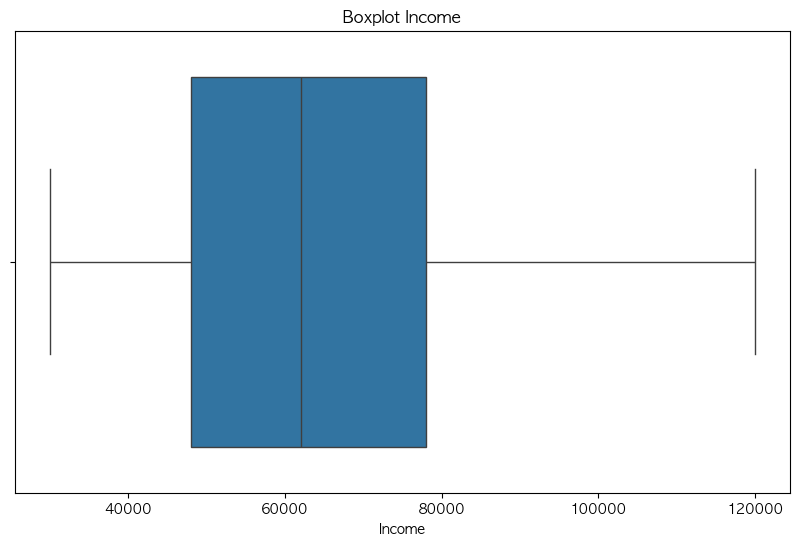

count    272388.000000
mean      64328.153223
std       21241.306119
min       30000.000000
25%       48000.000000
50%       62000.000000
75%       78000.000000
max      120000.000000
Name: income, dtype: float64

In [102]:
# 소득 분포 확인
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['income'].dropna())
plt.title('Boxplot Income')
plt.xlabel('Income')
plt.show()

df['income'].describe()

In [103]:
from datetime import datetime

# 연령대 구분
def category_age(age) :
    if pd.isna(age) :
        return 'unknown'
    age_int = int(age)
    if age_int >= 80 :
        return '80대 이상'
    return f'{(int(age) // 10) * 10}대'
df['age_group'] = df['age'].apply(category_age)

# 소득 구간 설정
def category_income(income) :
    if pd.isna(income) : return 'unknown'
    if income < 50000 : return '30k-50k'
    if income < 70000 : return '50k-70k'
    if income < 90000 : return '70k-90k'
    if income < 110000 : return '90k-110k'
    return '110k+'
df['income_group'] = df['income'].apply(category_income)

# 가입 기간 계산
df['became_member_on'] = pd.to_datetime(df['became_member_on'])
ref_date = df['became_member_on'].max() # 가장 최근 가입입을 오늘이라는 가정, RFM 분석에서는 데이터의 마지막 기록일이나 가입입을 기준점으로 잡는 것이 표준적인 관례
df['membership_days'] = (ref_date - df['became_member_on']).dt.days

display(ref_date)
display(df['membership_days'])

# 고객 정보 요약
customer_stats = df.groupby('customer_id').agg({
    'amount': 'sum',
    'gender': 'first',
    'age_group': 'first',
    'income_group': 'first',
    'membership_days': 'first'
}).reset_index()

# VIP 선정
vip_threshold = customer_stats['amount'].quantile(0.8)
customer_stats['is_vip'] = customer_stats['amount'] >= vip_threshold
customer_stats['is_vip_label'] = customer_stats['is_vip'].map({True: 'VIP', False: 'General'})

Timestamp('2018-07-26 00:00:00')

0          443
1          356
2           91
3          304
4          297
          ... 
306132     206
306133     109
306134    1768
306135     747
306136     958
Name: membership_days, Length: 306137, dtype: int64

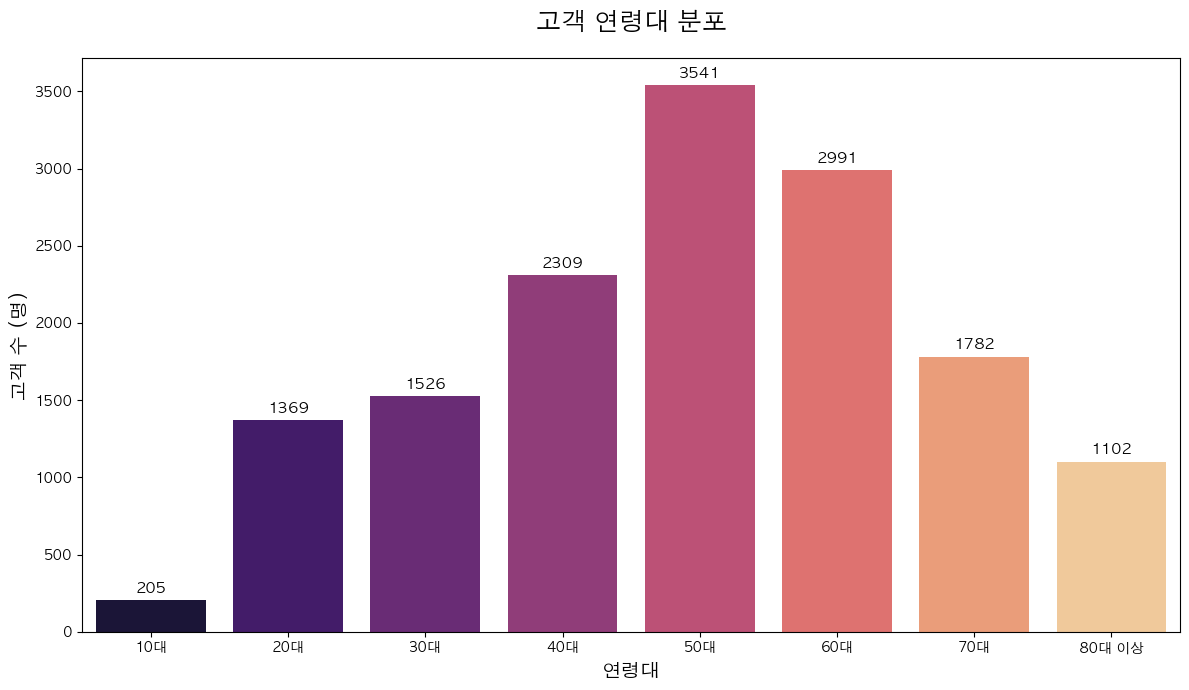

In [104]:
# 연령대 분포 분석
plt.figure(figsize=(12, 7))
age_order = ['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']

ax = sns.countplot(data=customer_stats, x='age_group', palette='magma', order=age_order)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)

plt.title('고객 연령대 분포', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('연령대', fontsize=14)
plt.ylabel('고객 수 (명)', fontsize=14)

plt.tight_layout()
plt.show()

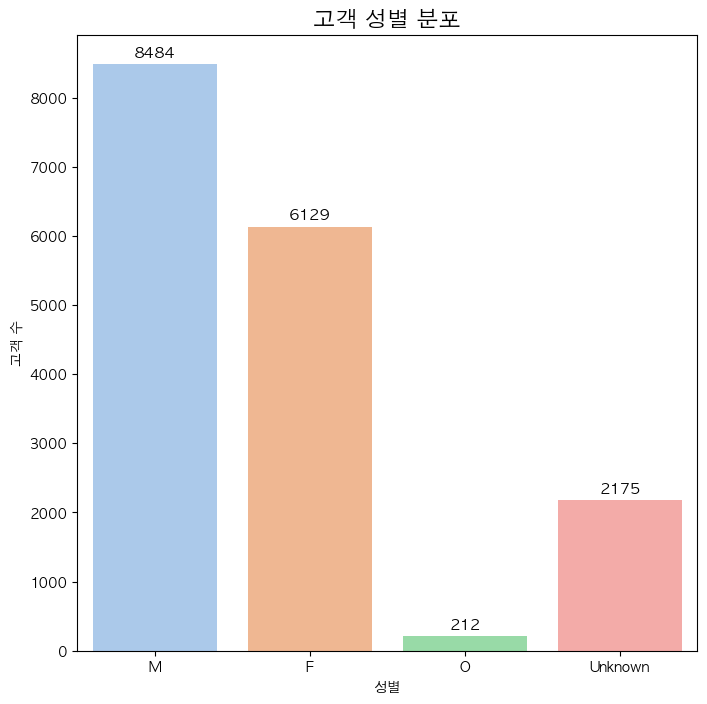

In [105]:
#고객 성별 분포
plt.figure(figsize=(8, 8))

ax = sns.countplot(data=customer_stats, x='gender', palette='pastel', order=['M', 'F', 'O', 'Unknown'])

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)

plt.title('고객 성별 분포', fontsize=16)
plt.xlabel('성별')
plt.ylabel('고객 수')
plt.show()

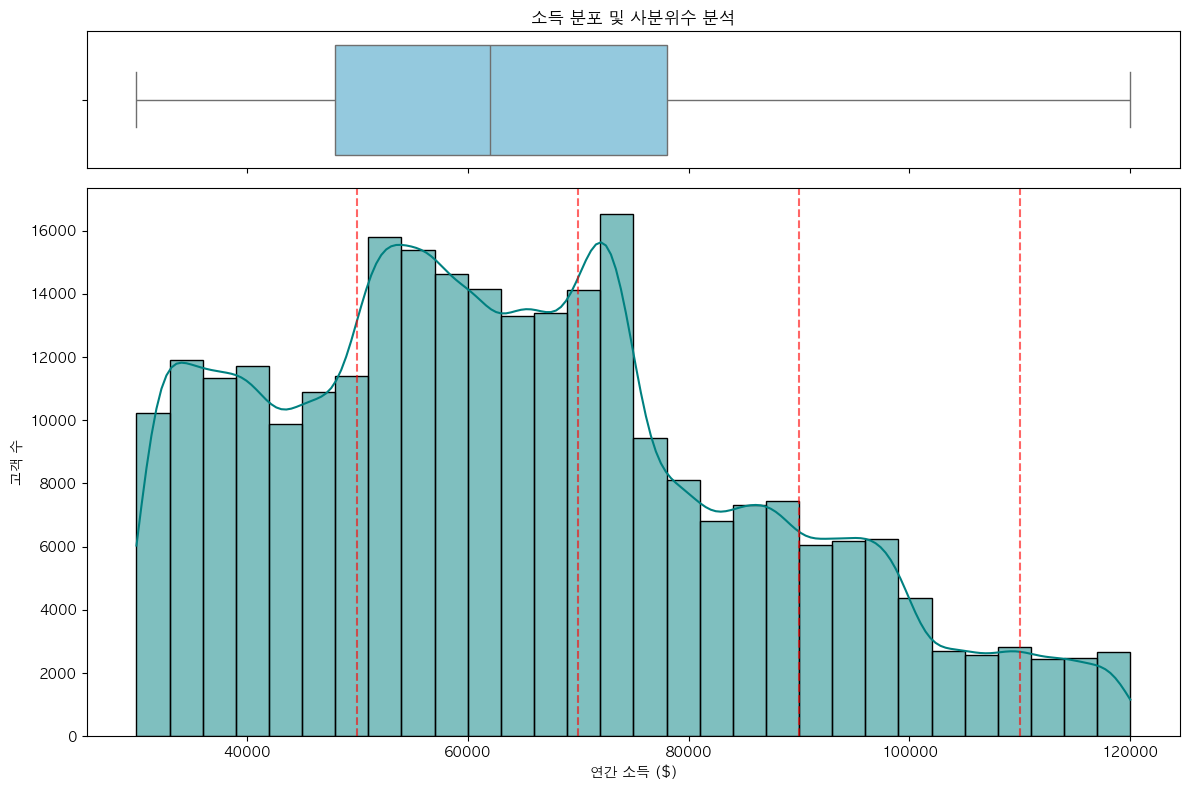

In [106]:
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(12, 8))

sns.boxplot(x=df['income'].dropna(), ax=ax_box, color='skyblue')
ax_box.set(title='소득 분포 및 사분위수 분석', xlabel='')

sns.histplot(df['income'].dropna(), kde=True, ax=ax_hist, color='teal', bins=30)
ax_hist.set(xlabel='연간 소득 ($)', ylabel='고객 수')

for x in [50000, 70000, 90000, 110000]:
    ax_hist.axvline(x=x, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

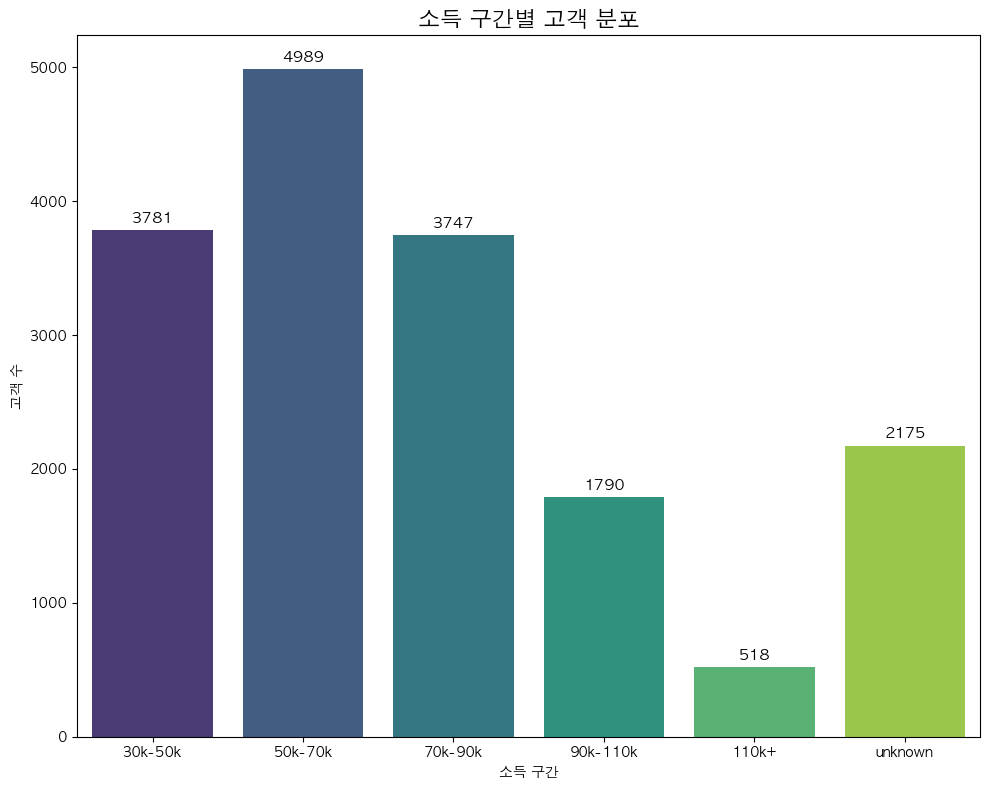

In [107]:
# 소득 구간별 분포
plt.figure(figsize=(10, 8))

income_order = ['30k-50k', '50k-70k', '70k-90k', '90k-110k', '110k+', 'unknown']

ax = sns.countplot(data=customer_stats, x='income_group', palette='viridis', order=income_order)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)

plt.title('소득 구간별 고객 분포', fontsize=16)
plt.xlabel('소득 구간')
plt.ylabel('고객 수')
plt.tight_layout()
plt.show()

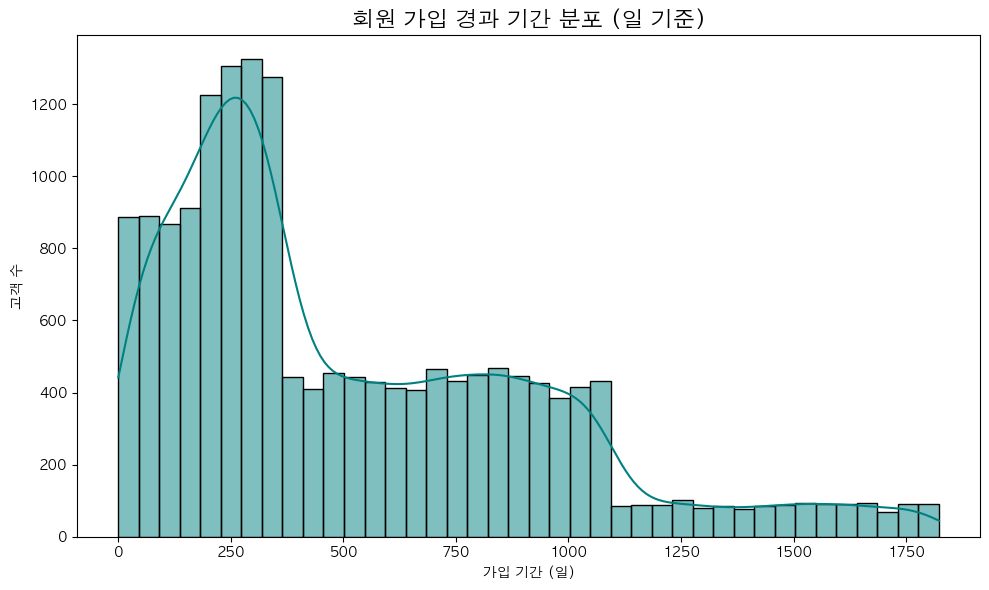

In [108]:
# 회원 가입 경과 기간 분석
plt.figure(figsize=(10, 6))
sns.histplot(customer_stats['membership_days'], bins=40, kde=True, color='teal')
plt.title('회원 가입 경과 기간 분포 (일 기준)', fontsize=16)
plt.xlabel('가입 기간 (일)')
plt.ylabel('고객 수')
plt.tight_layout()
plt.show()

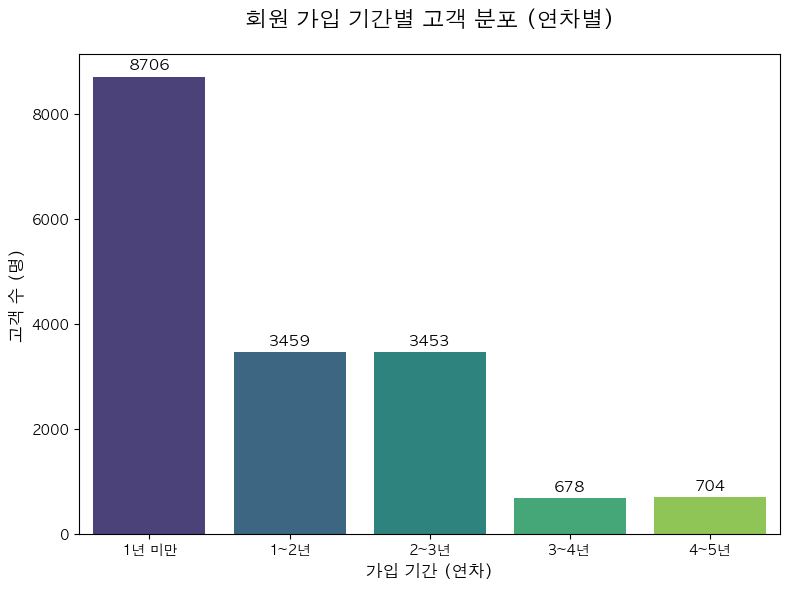

membership_tenure
1년 미만    8706
1~2년     3459
2~3년     3453
4~5년      704
3~4년      678
Name: count, dtype: int64

In [109]:
def category_membership(days):
    years = days / 365.25
    if years < 1: return '1년 미만'
    if years < 2: return '1~2년'
    if years < 3: return '2~3년'
    if years < 4: return '3~4년'
    if years < 5: return '4~5년'
    return '5년 이상'

customer_stats['membership_tenure'] = customer_stats['membership_days'].apply(category_membership)

plt.figure(figsize=(8, 6))
tenure_order = ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년']

ax = sns.countplot(data=customer_stats, x='membership_tenure', order=tenure_order, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)

plt.title('회원 가입 기간별 고객 분포 (연차별)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('가입 기간 (연차)', fontsize=12)
plt.ylabel('고객 수 (명)', fontsize=12)
plt.tight_layout()
plt.show()

customer_stats['membership_tenure'].value_counts()

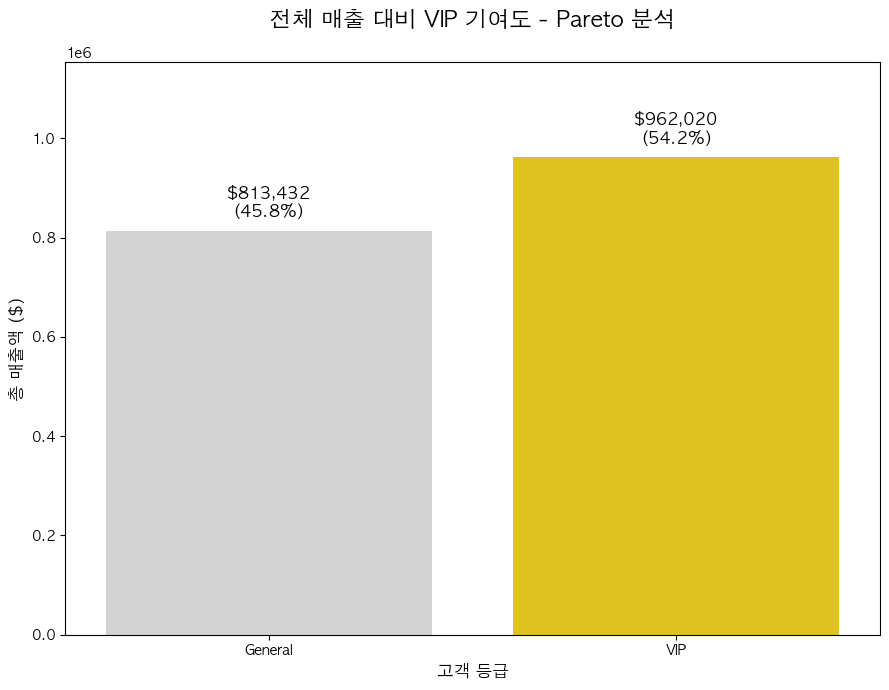

In [110]:
revenue_stats = customer_stats.groupby('is_vip_label')['amount'].sum().reset_index()
total_revenue = revenue_stats['amount'].sum()
revenue_stats['share_pct'] = (revenue_stats['amount'] / total_revenue) * 100

plt.figure(figsize=(9, 7))
ax = sns.barplot(data=revenue_stats, x='is_vip_label', y='amount', palette=['lightgrey', '#FFD700'])

for i, p in enumerate(ax.patches):
    amount = revenue_stats.loc[i, 'amount']
    percent = revenue_stats.loc[i, 'share_pct']
    ax.annotate(f'${amount:,.0f}\n({percent:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 20), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('전체 매출 대비 VIP 기여도 - Pareto 분석', fontsize=16, pad=25)
plt.xlabel('고객 등급', fontsize=12)
plt.ylabel('총 매출액 ($)', fontsize=12)
plt.ylim(0, max(revenue_stats['amount']) * 1.2)
plt.tight_layout()
plt.show()

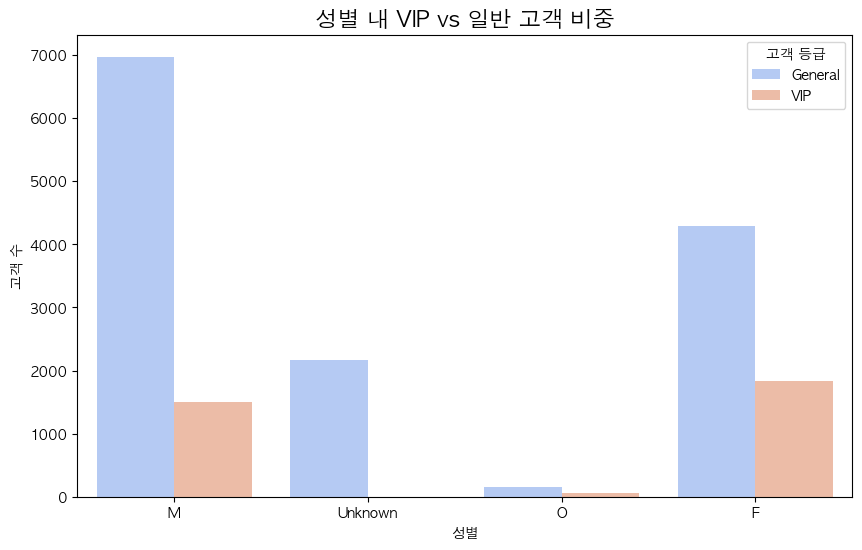

In [111]:
plt.figure(figsize=(10, 6))
sns.countplot(data=customer_stats, x='gender', hue='is_vip_label', palette='coolwarm')
plt.title('성별 내 VIP vs 일반 고객 비중', fontsize=16)
plt.xlabel('성별')
plt.ylabel('고객 수')
plt.legend(title='고객 등급')
plt.show()

In [112]:
def category_age_v2(age):
    if pd.isna(age) or age > 100: return 'unknown'
    age_int = int(age)
    if age_int >= 80: return '80대 이상'
    return f'{(age_int // 10) * 10}대'

def categorize_income(income):
    if pd.isna(income): return 'Unknown'
    if income < 50000: return '30k-50k'
    if income < 70000: return '50k-70k'
    if income < 90000: return '70k-90k'
    if income < 110000: return '90k-110k'
    return '110k+'

def categorize_membership(days):
    years = days / 365.25
    if years < 1: return '1년 미만'
    if years < 2: return '1~2년'
    if years < 3: return '2~3년'
    if years < 4: return '3~4년'
    if years < 5: return '4~5년'
    return '5년 이상'

# 가입일 처리 및 일수 계산
df['became_member_on'] = pd.to_datetime(df['became_member_on'])
ref_date = df['became_member_on'].max()
df['membership_days'] = (ref_date - df['became_member_on']).dt.days

# 고객별 집계
customer_stats = df.groupby('customer_id').agg({
    'amount': 'sum',
    'gender': 'first',
    'age': 'first',      
    'income': 'first',  
    'membership_days': 'first'
}).reset_index()

# 구간화 컬럼 생성
customer_stats['age_group'] = customer_stats['age'].apply(category_age_v2)
customer_stats['income_group'] = customer_stats['income'].apply(categorize_income)
customer_stats['membership_tenure'] = customer_stats['membership_days'].apply(categorize_membership)

# VIP
vip_threshold = customer_stats['amount'].quantile(0.8)
customer_stats['is_vip'] = customer_stats['amount'] >= vip_threshold
customer_stats['is_vip_label'] = customer_stats['is_vip'].map({True: 'VIP', False: 'General'})

print(f"컬럼: {customer_stats.columns.tolist()}")

컬럼: ['customer_id', 'amount', 'gender', 'age', 'income', 'membership_days', 'age_group', 'income_group', 'membership_tenure', 'is_vip', 'is_vip_label']


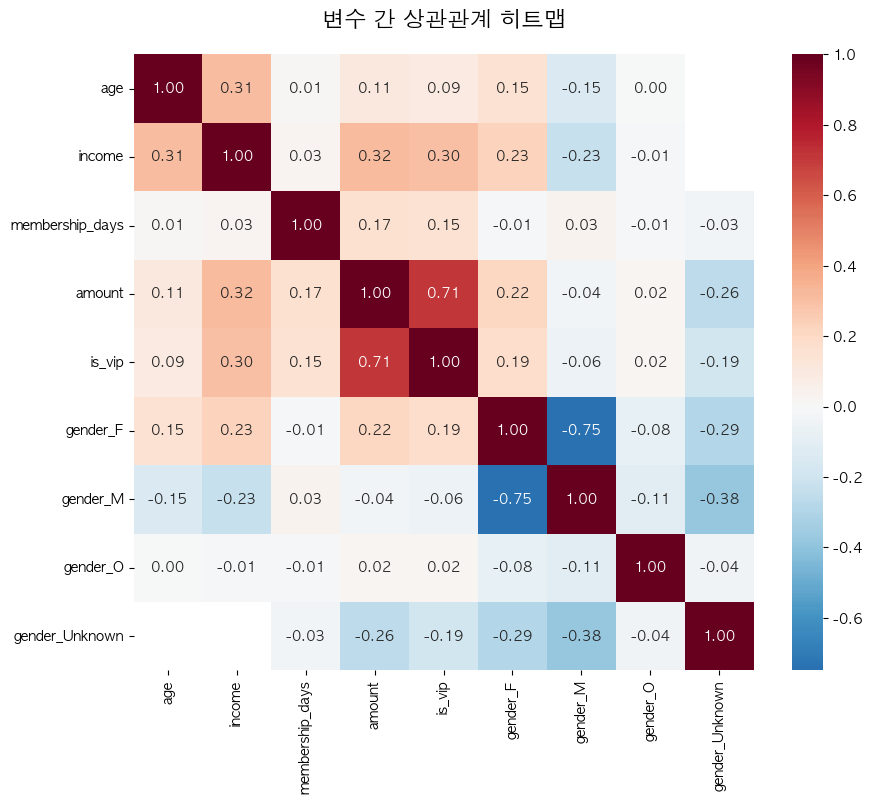

In [113]:
gender_dummies = pd.get_dummies(customer_stats['gender'], prefix='gender')

corr_features = ['age', 'income', 'membership_days', 'amount', 'is_vip']
corr_data = pd.concat([customer_stats[corr_features], gender_dummies], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('변수 간 상관관계 히트맵', fontsize=16, pad=20)
plt.show()

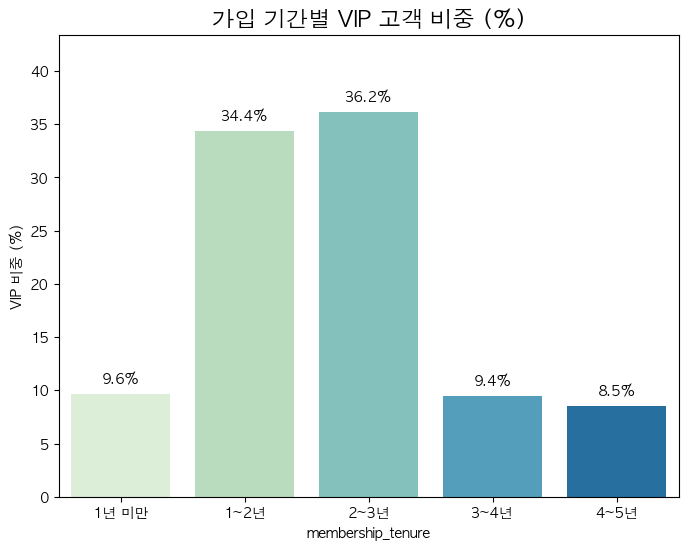

In [114]:
plt.figure(figsize=(8, 6))
tenure_order = ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년']

tenure_vip_pct = pd.crosstab(customer_stats['membership_tenure'], customer_stats['is_vip'], normalize='index')[True] * 100
tenure_vip_pct = tenure_vip_pct.reindex(tenure_order)

ax = sns.barplot(x=tenure_vip_pct.index, y=tenure_vip_pct.values, palette='GnBu')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('가입 기간별 VIP 고객 비중 (%)', fontsize=16)
plt.ylabel('VIP 비중 (%)')
plt.ylim(0, max(tenure_vip_pct) * 1.2)
plt.show()

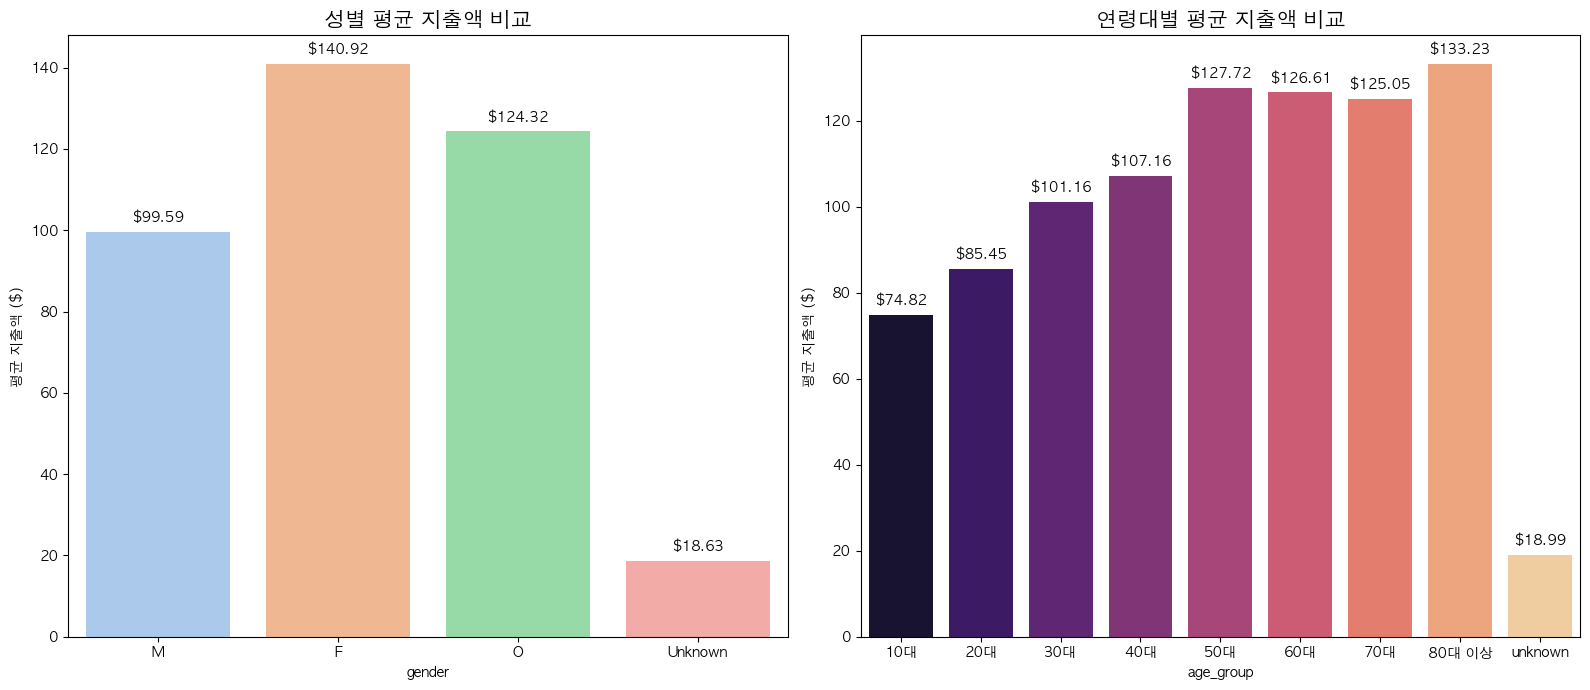

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 성별 평균 지출액
gender_avg_amount = customer_stats.groupby('gender')['amount'].mean().reindex(['M', 'F', 'O', 'Unknown'])
sns.barplot(x=gender_avg_amount.index, y=gender_avg_amount.values, ax=axes[0], palette='pastel')
axes[0].set_title('성별 평균 지출액 비교', fontsize=15)
axes[0].set_ylabel('평균 지출액 ($)')

for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# 연령대별 평균 지출액
age_order = ['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상', 'unknown']
age_avg_amount = customer_stats.groupby('age_group')['amount'].mean().reindex(age_order)
sns.barplot(x=age_avg_amount.index, y=age_avg_amount.values, ax=axes[1], palette='magma')
axes[1].set_title('연령대별 평균 지출액 비교', fontsize=15)
axes[1].set_ylabel('평균 지출액 ($)')

for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

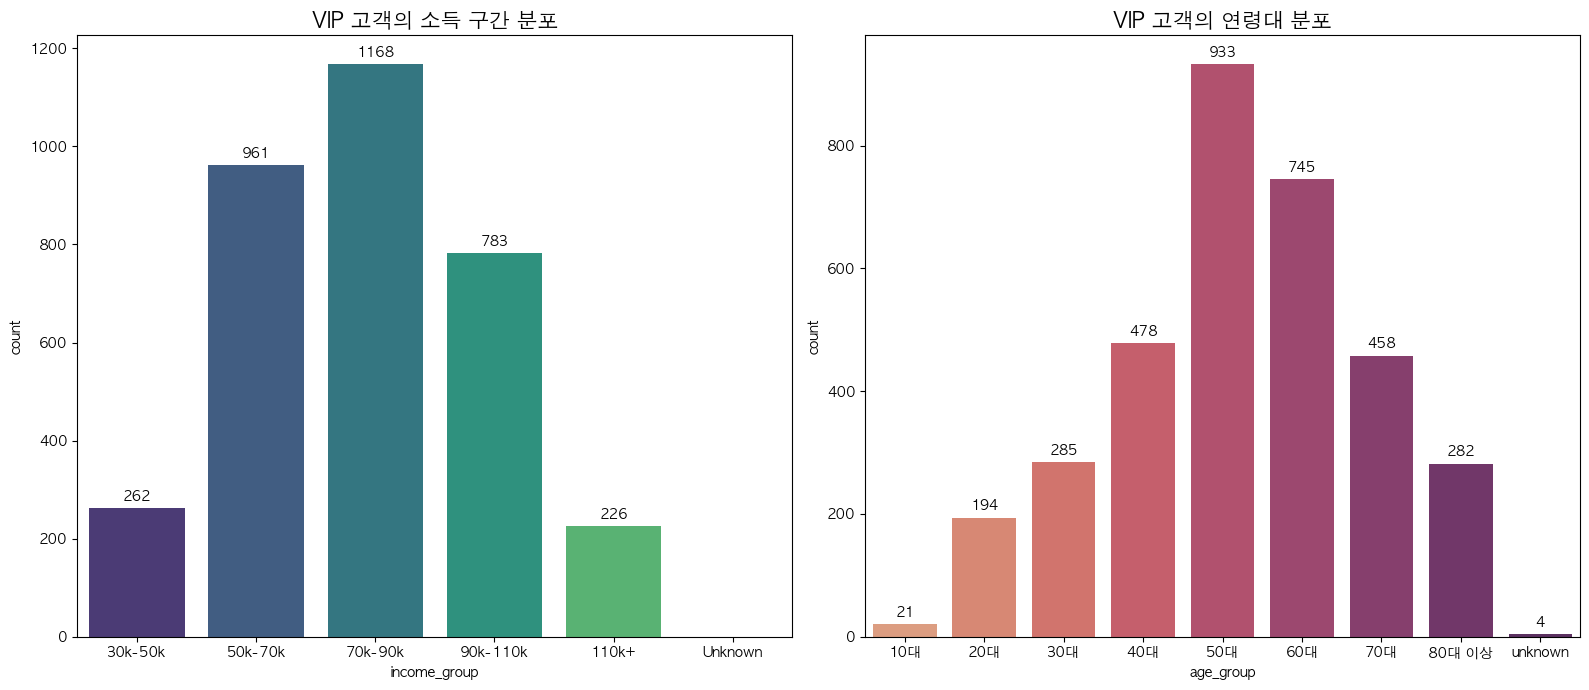

--- VIP 고객 프로필 요약 ---
VIP 평균 소득: $77,378.24
VIP 평균 연령: 57.1세
VIP 여성 비중:  53.9%


In [116]:
vips = customer_stats[customer_stats['is_vip'] == True]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# VIP의 소득 구간 분포
income_order = ['30k-50k', '50k-70k', '70k-90k', '90k-110k', '110k+', 'Unknown']
sns.countplot(data=vips, x='income_group', order=income_order, ax=axes[0], palette='viridis')
axes[0].set_title('VIP 고객의 소득 구간 분포', fontsize=15)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)

# VIP의 연령대 분포
sns.countplot(data=vips, x='age_group', order=age_order, ax=axes[1], palette='flare')
axes[1].set_title('VIP 고객의 연령대 분포', fontsize=15)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

# VIP 프로필 요약
print("--- VIP 고객 프로필 요약 ---")
print(f"VIP 평균 소득: ${vips['income'].mean():,.2f}")
print(f"VIP 평균 연령: {vips['age'].mean():.1f}세")
print(f"VIP 여성 비중: {(vips['gender'] == 'F').mean()*100: .1f}%")

#### 여성 고객의 평균 지출액($175.09)이 남성($116.61)보다 약 50% 이상 높음

#### 50대부터 80대 이상까지 고연령층의 평균 지출액이 $130~$140대로 높게 유지되는 반면 10~20대는 상대적으로 낮은 소비력을 보임

#### VIP 고객들은 7만 달러 이상의 고소득 구간에 밀집되어 있음 특히 소득이 높아질수록 VIP 숫자가 계단식으로 증가하는 것이 눈에 보임

#### VIP 고객 수에서 50대가 압도적 1위, 40~60대가 그 뒤에 위치

#### 성별이나 연령 정보를 기입하지 않은 고객들의 평균 지출액은 $21.57로 매우 낮음으로 보아 충성도가 낮거나 가끔 방문하는 고객일 가능성이 큼

In [ ]:
# 1. 고객별 구매 행동(RFM) 계산
tx_df = df[df['event'] == 'transaction']
customer_rfm = tx_df.groupby('customer_id').agg({
    'amount': 'sum',
    'time': ['count', 'max']
}).reset_index()
customer_rfm.columns = ['customer_id', 'total_spend', 'tx_count', 'last_time']

# Recency 계산
max_time = df['time'].max() # 데이터셋에서 오늘 혹은 현재의 기준이 없기 때문에 타임 컬럼의 마지막 날짜로 가정하에 분석 진행
customer_rfm['recency'] = max_time - customer_rfm['last_time']

# 오퍼 반응 지표 계산
offer_stats = df[df['event'].isin(['viewed', 'completed'])].groupby(['customer_id', 'event']).size().unstack(fill_value=0).reset_index()
offer_stats['completion_rate'] = (offer_stats.get('completed', 0) / offer_stats.get('viewed', 1).replace(0, 1)).fillna(0)

# 정보성 오퍼 선호도 계산
info_views = df[(df['event'] == 'viewed') & (df['offer_label'].str.contains('informational', na=False))]
info_stats = info_views.groupby('customer_id').size().reset_index(name='info_view_count')

# 데이터셋 병합
final_df = customer_rfm.merge(offer_stats, on='customer_id', how='left')
final_df = final_df.merge(info_stats, on='customer_id', how='left').fillna(0)
final_df = final_df.merge(customer_stats[['customer_id', 'gender', 'age_group', 'income', 'income_group']], on='customer_id', how='left')

In [128]:
# 임계치 설정
q1_spend, q3_spend = final_df['total_spend'].quantile([0.25, 0.75])
q1_tx, q3_tx = final_df['tx_count'].quantile([0.25, 0.75])
q3_recency = final_df['recency'].quantile(0.75)

def segment_customers(row):
    # 고빈도·고매출 고객 : 횟수와 금액 모두 상위 25% - 최우수 고객
    if row['total_spend'] >= q3_spend and row['tx_count'] >= q3_tx:
        return '고빈도·고매출 고객'
    
    # 저빈도·저매출 고객 : 횟수와 금액 모두 하위 25% - 이탈 또는 신규
    if row['total_spend'] <= q1_spend and row['tx_count'] <= q1_tx:
        return '저빈도·저매출 고객'
    
    # 휴면 위험 고객 : 구매내역은 어느 정도 있으나 최근 방문 공백이 매우 김
    if row['recency'] >= q3_recency:
        return '휴면 위험 고객'
    
    # 오퍼 반응형 고객 : 쿠폰을 보면 거의 반드시 사용하는 고객 (반응률 70% 이상)
    if row['completion_rate'] >= 0.7:
        return '오퍼 반응형 고객'
    
    # 정보성 오퍼 선호 고객 : 혜택보다 브랜드 소식 조회가 더 많음
    if row['info_view_count'] > 0 and (row['info_view_count'] >= row.get('viewed', 0) * 0.5):
        return '정보성 오퍼 선호 고객'
    
    return '일반 고객'

final_df['segment'] = final_df.apply(segment_customers, axis=1)

In [129]:
segment_summary = final_df.groupby('segment').agg({
    'customer_id': 'count',
    'total_spend': 'mean',
    'income': 'mean',
    'recency': 'mean'
}).rename(columns={'customer_id': '고객수'}).sort_values('total_spend', ascending=False)

display(segment_summary)

,고객수,total_spend,income,recency
segment,,,,
고빈도·고매출 고객,2190,277.192434,66623.572407,50.791781
오퍼 반응형 고객,3796,143.373946,70880.236305,47.551106
휴면 위험 고객,2820,92.911748,74133.358808,193.317021
정보성 오퍼 선호 고객,1054,85.107211,62464.208243,48.637571
일반 고객,4068,60.013739,58429.499072,44.840708
저빈도·저매출 고객,2650,10.680385,52482.834994,130.419623


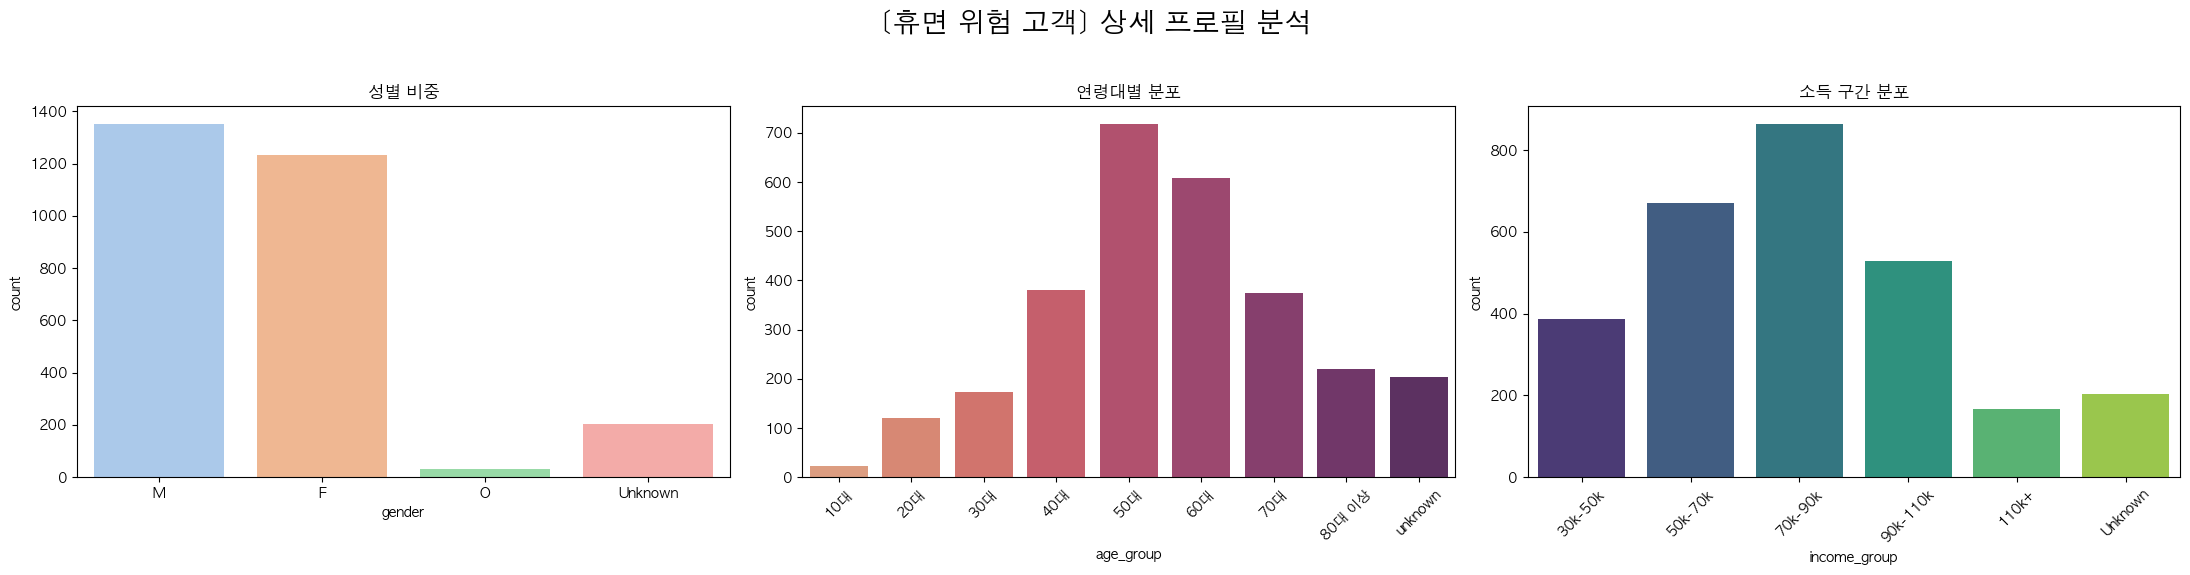

In [132]:
def analyze_segment_detail(segment_name):
    data = final_df[final_df['segment'] == segment_name]
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'[{segment_name}] 상세 프로필 분석', fontsize=20, fontweight='bold')

    # 성별 분포
    sns.countplot(data=data, x='gender', ax=axes[0], palette='pastel', order=['M', 'F', 'O', 'Unknown'])
    axes[0].set_title('성별 비중')

    # 연령대 분포
    age_order = ['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상', 'unknown']
    sns.countplot(data=data, x='age_group', ax=axes[1], palette='flare', order=age_order)
    axes[1].set_title('연령대별 분포')
    axes[1].tick_params(axis='x', rotation=45)

    # 소득 수준 분포
    income_order = ['30k-50k', '50k-70k', '70k-90k', '90k-110k', '110k+', 'Unknown']
    sns.countplot(data=data, x='income_group', ax=axes[2], palette='viridis', order=income_order)
    axes[2].set_title('소득 구간 분포')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 휴면 위험 고객에 대한 상세 분석
analyze_segment_detail('휴면 위험 고객')

#### 남성 휴먼 고객이 여성보다 조금 더 많아 보이지만 고객 비율로 따지면 여성 고객의 이탈률이 더 크다(남성 : 17.4%, 여성 : 22.1%)

#### 주요 지지층인 40-60대와 중위 소득 계층이 종모양의 정점을 이루며 이탈

#### 휴면 위험군에 속한 여성 & 중장년층이 과거에 가장 많이 완료했던 오퍼 유형이 무엇인지 확인 후 액션 진행

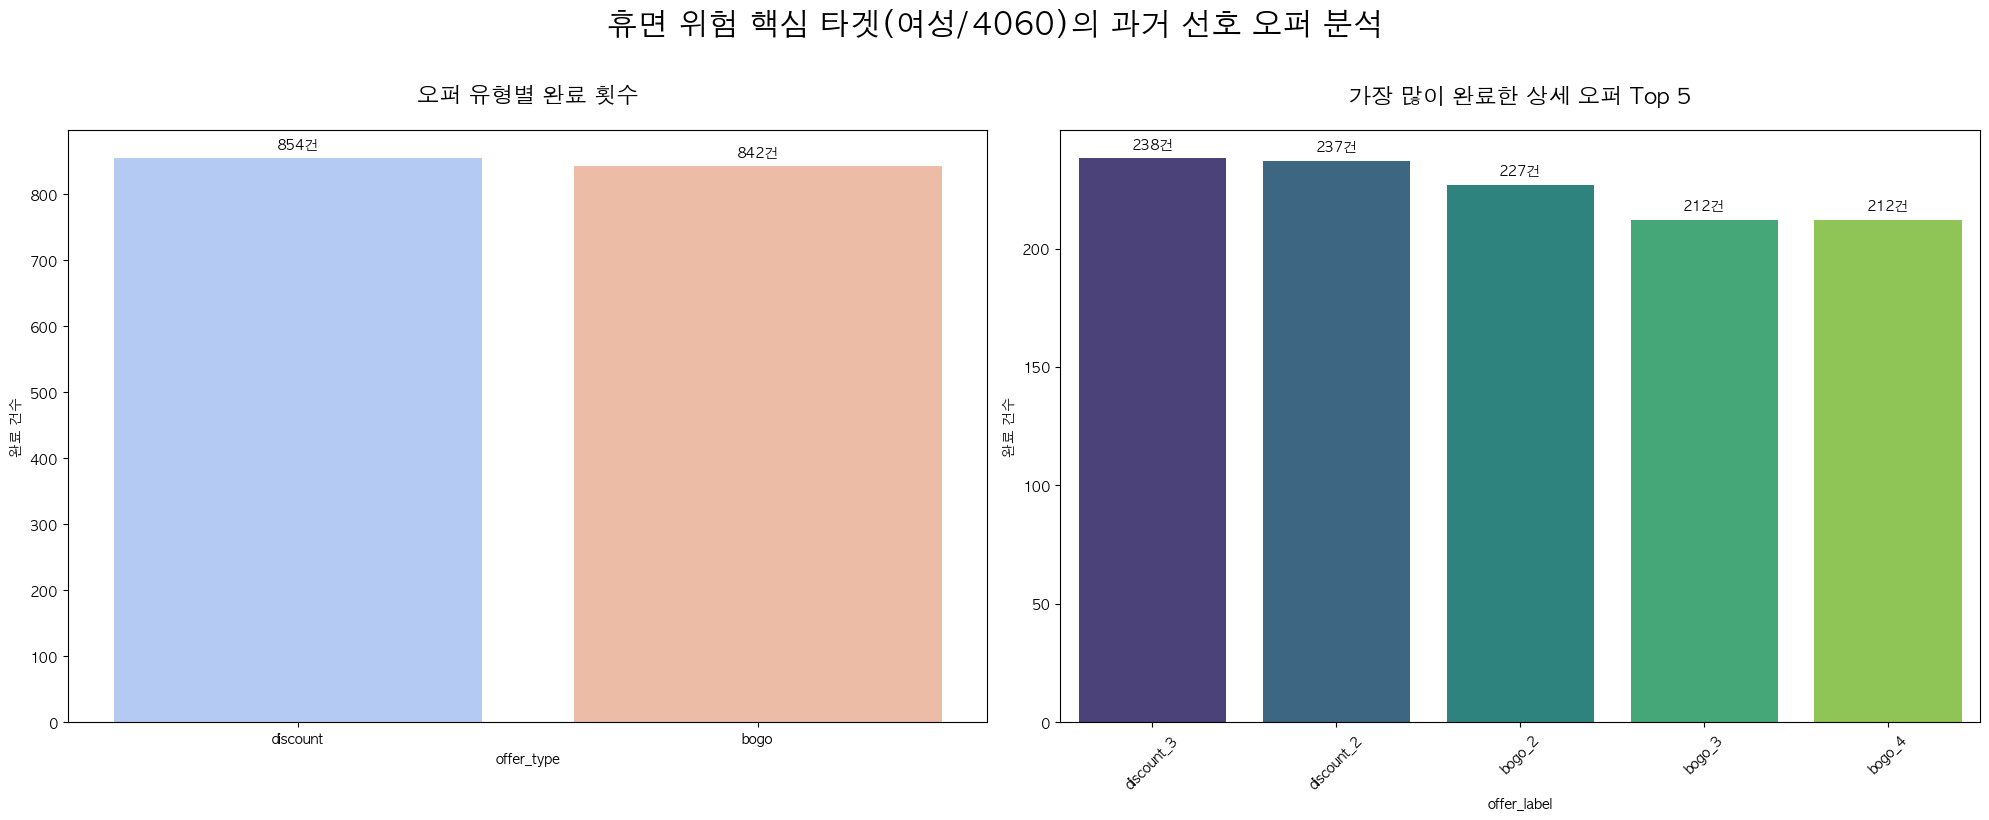

분석 결과 요약
- 분석 대상 핵심 인원: 796명
- 가장 선호하는 오퍼 유형: discount (854건)


In [138]:
# 분석 대상 정의: 휴면 위험군 중 '여성' & '40~60대' 핵심 타겟 추출
dormant_risk_core = final_df[
    (final_df['segment'] == '휴면 위험 고객') & 
    (final_df['gender'] == 'F') & 
    (final_df['age_group'].isin(['40대', '50대', '60대']))
]

# 이들이 과거에 '완료(completed)'했던 오퍼 이력 추출
core_ids = dormant_risk_core['customer_id'].unique()
past_completions = df[(df['customer_id'].isin(core_ids)) & (df['event'] == 'completed')]

# 오퍼 유형 추출 (bogo, discount 등)
past_completions['offer_type'] = past_completions['offer_label'].apply(
    lambda x: x.split('_')[0] if pd.notna(x) else 'Unknown'
)

offer_type_counts = past_completions['offer_type'].value_counts()
offer_label_counts = past_completions['offer_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

fig.suptitle('휴면 위험 핵심 타겟(여성/4060)의 과거 선호 오퍼 분석', fontsize=22, fontweight='bold', y=1.02)

# 오퍼 유형별 선호도
sns.barplot(x=offer_type_counts.index, y=offer_type_counts.values, ax=axes[0], palette='coolwarm')
axes[0].set_title('오퍼 유형별 완료 횟수', fontsize=16, pad=20) # ax.set_title에서는 pad 사용 가능
axes[0].set_ylabel('완료 건수')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}건', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# 상세 오퍼 라벨별 선호도
sns.barplot(x=offer_label_counts.head(5).index, y=offer_label_counts.head(5).values, ax=axes[1], palette='viridis')
axes[1].set_title('가장 많이 완료한 상세 오퍼 Top 5', fontsize=16, pad=20)
axes[1].set_ylabel('완료 건수')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}건', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

print(f"분석 결과 요약")
print(f"- 분석 대상 핵심 인원: {len(core_ids)}명")
print(f"- 가장 선호하는 오퍼 유형: {offer_type_counts.idxmax()} ({offer_type_counts.max()}건)")

##### 가장 반응이 좋았던 discount_3 스타일의 오퍼 발송
##### AB테스트 진행 bogo_2 오퍼를 2차로 발송하여 잔류를 유도

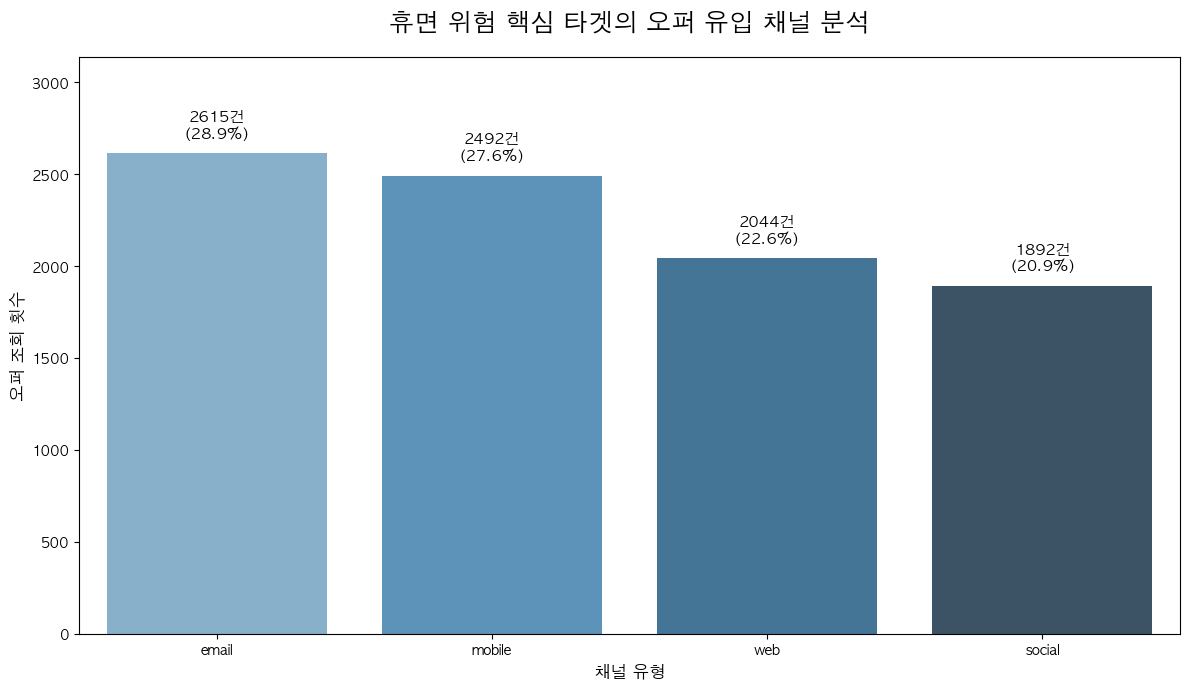

📊 채널 분석 요약
- 가장 영향력 있는 채널: email (2615.0건 조회)


In [139]:
# 분석 대상: 휴면 위험 핵심 타겟 (여성 & 40~60대)
core_ids = final_df[
    (final_df['segment'] == '휴면 위험 고객') & 
    (final_df['gender'] == 'F') & 
    (final_df['age_group'].isin(['40대', '50대', '60대']))
]['customer_id'].unique()

# 오퍼를 조회했던 데이터만 추출
core_views = df[(df['customer_id'].isin(core_ids)) & (df['event'] == 'viewed')]

# 채널별 노출 횟수 집계
channels = ['email', 'mobile', 'social', 'web']
channel_totals = core_views[channels].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=channel_totals.index, y=channel_totals.values, palette='Blues_d')

plt.title('휴면 위험 핵심 타겟의 오퍼 유입 채널 분석', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('오퍼 조회 횟수', fontsize=12)
plt.xlabel('채널 유형', fontsize=12)

total_views = channel_totals.sum()
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_views) * 100
    ax.annotate(f'{int(height)}건\n({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 20), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.ylim(0, max(channel_totals.values) * 1.2) 
plt.tight_layout()
plt.show()

print(f"채널 분석 요약")
print(f"- 가장 영향력 있는 채널: {channel_totals.idxmax()} ({channel_totals.max()}건 조회)")

##### email을 통해 오퍼 진행

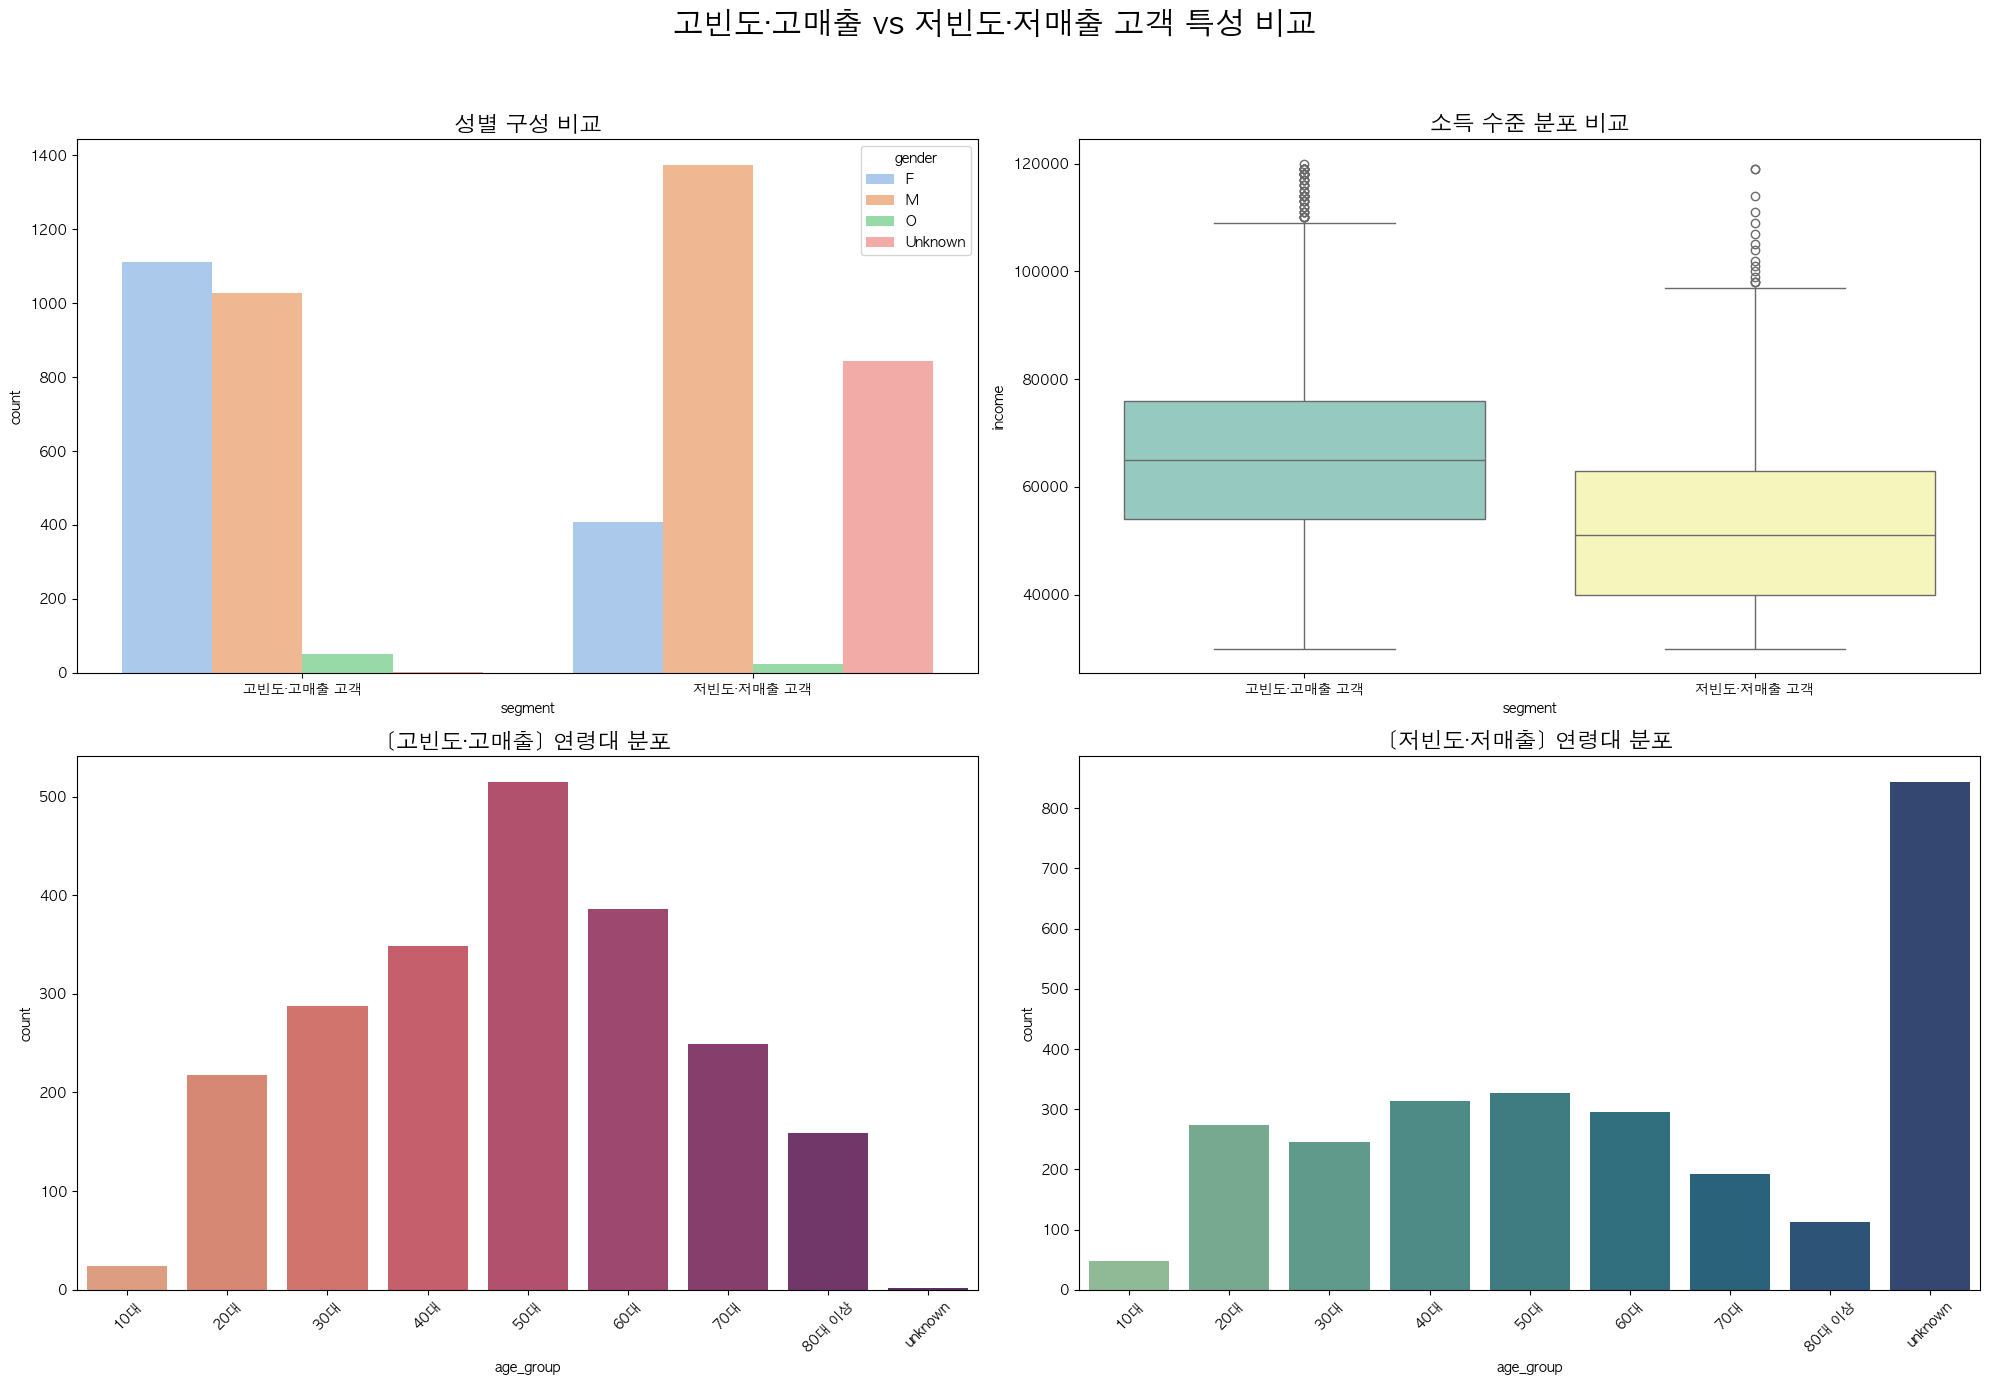

[고빈도·고매출] 평균 지출: $277.19 / 평균 소득: $66,623.57
[저빈도·저매출] 평균 지출: $10.68 / 평균 소득: $52,482.83


In [141]:
# 2. 비교 대상 데이터 필터링
high_high = final_df[final_df['segment'] == '고빈도·고매출 고객']
low_low = final_df[final_df['segment'] == '저빈도·저매출 고객']

# 두 데이터 합치기 (비교 시각화용)
compare_df = pd.concat([high_high, low_low])

# ---------------------------------------------------------
# 3. 시각화: 두 집단은 무엇이 다른가?
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('고빈도·고매출 vs 저빈도·저매출 고객 특성 비교', fontsize=22, fontweight='bold', y=0.95)

# (1) 성별 구성 비교
sns.countplot(data=compare_df, x='segment', hue='gender', ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('성별 구성 비교', fontsize=16)

# (2) 평균 소득 비교 (박스플롯)
sns.boxplot(data=compare_df, x='segment', y='income', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('소득 수준 분포 비교', fontsize=16)

# (3) 연령대 분포 비교 (고빈도·고매출)
sns.countplot(data=high_high, x='age_group', ax=axes[1, 0], palette='flare', 
              order=['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상', 'unknown'])
axes[1, 0].set_title('[고빈도·고매출] 연령대 분포', fontsize=16)
axes[1, 0].tick_params(axis='x', rotation=45)

# (4) 연령대 분포 비교 (저빈도·저매출)
sns.countplot(data=low_low, x='age_group', ax=axes[1, 1], palette='crest',
              order=['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상', 'unknown'])
axes[1, 1].set_title('[저빈도·저매출] 연령대 분포', fontsize=16)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

# 4. 요약 통계량 출력
print(f"[고빈도·고매출] 평균 지출: ${high_high['total_spend'].mean():.2f} / 평균 소득: ${high_high['income'].mean():,.2f}")
print(f"[저빈도·저매출] 평균 지출: ${low_low['total_spend'].mean():.2f} / 평균 소득: ${low_low['income'].mean():,.2f}")

##### 성별 -> 여성이 압도적으로 형성
##### 소득 -> 두 그룹의 평균 소득 격차는 $14,140
##### 연령대 -> 고빈도 : 50대가 정점을 찍는 종모양 분포, 저빈도 : Unknown

##### 제안
##### 고빈도고매출 고객 : 이미 돈을 잘 쓰고 있기에 할인은 큰 의미가 없음, 한정판 굿즈나 신메뉴 우선 시음권 같은 특별 대우를 통해 만족감을 충족시켜야 한다
##### 저빈도저매출 고객 : 정보 입력시 무료 음료권 증정과 같은 이벤트로 Unknown 고객들의 정보를 파악, 이번 주 3번 방문 시 리워드 $10 증정 과 같은 방문을 유도 하는 미션형 오퍼로 방문 빈도를 강제로 끌러오리는 전략 필요

In [143]:
# 오퍼 반응형 고객
# 정보성 오퍼 선호 고객
# 일반 고객
# ----------------
# 세그먼트 상세 분석 필요